In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [12]:
# Step 1: Generate Synthetic Data
torch.manual_seed(42)
X = torch.rand(100, 1) * 10  # Random values between 0 and 10
y = 3 * X + 7 + torch.randn(100, 1) * 5  # y = 3X + 7 with noise


In [13]:
# Step 2: Convert to NumPy for train-test split
X_numpy = X.numpy()
y_numpy = y.numpy()

In [14]:
# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_numpy, y_numpy, test_size=0.2, random_state=42)

# Convert back to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [15]:

# Step 3: Define the Linear Regression Model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)  # 1 input feature, 1 output feature

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()



In [16]:

# Step 4: Define Loss and Optimizer
criterion = nn.MSELoss()  # Mean Squared Error Loss
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient Descent

# Step 5: Training the Model
epochs = 1000
for epoch in range(epochs):
    # Forward pass
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:  # Print every 100 epochs
        print(f'Epoch {epoch+1}, Loss: {loss.item()}')


torch.save(model.state_dict(), 'trained_model.pth')

Epoch 100, Loss: 23.33530616760254
Epoch 200, Loss: 19.67551040649414
Epoch 300, Loss: 18.254056930541992
Epoch 400, Loss: 17.701969146728516
Epoch 500, Loss: 17.487537384033203
Epoch 600, Loss: 17.404251098632812
Epoch 700, Loss: 17.371906280517578
Epoch 800, Loss: 17.35934066772461
Epoch 900, Loss: 17.354459762573242
Epoch 1000, Loss: 17.352563858032227


In [17]:
# Step 6: Evaluate the Model
model.eval()  # Switch to evaluation mode
with torch.no_grad():
    test_predictions = model(X_test)
    test_loss = criterion(test_predictions, y_test)
    print(f'Test Loss: {test_loss.item()}')

Test Loss: 13.5271635055542


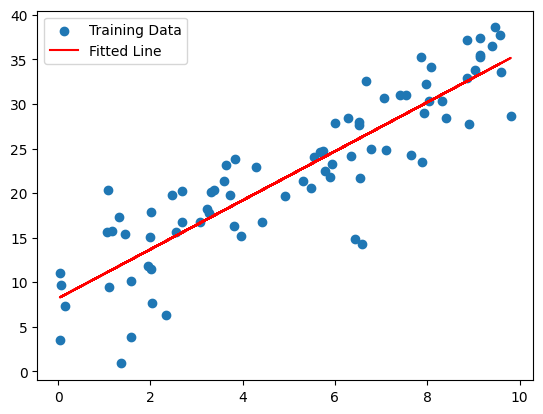

In [18]:
# Step 7: Visualize Training Results
with torch.no_grad():
    predicted = model(X_train).numpy()
plt.scatter(X_train.numpy(), y_train.numpy(), label='Training Data')
plt.plot(X_train.numpy(), predicted, color='red', label='Fitted Line')
plt.legend()
plt.show()

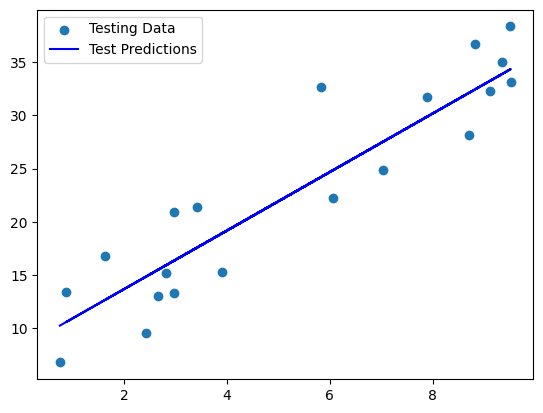

In [19]:
# Step 8: Visualize Testing Results
with torch.no_grad():
    test_predicted = model(X_test).numpy()
plt.scatter(X_test.numpy(), y_test.numpy(), label='Testing Data')
plt.plot(X_test.numpy(), test_predicted, color='blue', label='Test Predictions')
plt.legend()
plt.show()